# Libraries

In [1]:
import pandas as pd
import pypdf
import json
import random
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch import Generator
from dotenv import load_dotenv
load_dotenv()
from tqdm import tqdm

In [2]:
import os
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import evaluate
from bert_score import score as bert_score

In [3]:
from coeur.score import Coeur

# Data Preparation

In [4]:
class SpecRetriever:
    def load_specs(self, path: str) -> list[str]:
        directory = PyPDFLoader(path).load()
        chunk_overlap = int(self.chunk_size * self.overlap_rate)
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=self.chunk_size,
            chunk_overlap=chunk_overlap
        )

        docs = text_splitter.split_documents(directory)
        for doc in docs:
            doc.page_content = doc.page_content.replace("\n", " ")\
                                            .replace("•", " ") \
                                            .replace("♦", " ") \
                                            .replace("  ", " ") \
                                            .strip()
        return docs

    def __init__(self, path: str, docs=None, index=None, model=None,
                 chunk_size: int = 200, overlap_rate: float = 0.15):
        self.model = model if model is not None else SentenceTransformer('all-MiniLM-L6-v2')
        self.chunk_size = chunk_size
        self.overlap_rate = overlap_rate

        if index is not None and docs is not None:
            self.index = index
            self.docs = docs
        else:
            self.docs = self.load_specs(path)
            vectors = []
            for doc in self.docs:
                vectors.append(self.model.encode(doc.page_content))
            dimension = vectors[0].shape[0]
            self.index = faiss.IndexFlatL2(dimension)
            self.index.add(np.array(vectors))

    def get_similar_specs(self, spec: str, top_k: int = 5):
        spec_vector = self.model.encode(spec)
        _, indices = self.index.search(np.array([spec_vector]), top_k)
        similar_docs = [self.docs[i].page_content for i in indices[0]]
        return similar_docs

In [5]:
def req_to_dataframe(data: dict) -> pd.DataFrame:
        rows = []
        for source in data.keys():
            current_rows = []
            for epic in data[source]["epics"]:
                epic_name = epic["epic"].strip()
                for story in epic["user_stories"]:
                    row = {
                        "source": source,
                        "epic": epic_name,
                        "user_story": story["user_story"].strip(),
                        "acceptance_criteria": story["acceptance_criteria"],
                        "independent": story["independent"],
                        "negotiable": story["negotiable"],
                        "valuable": story["valuable"],
                        "estimable": story["estimable"],
                        "small": story["small"],
                        "testable": story["testable"]
                    }
                    current_rows.append(row)
            rows.extend(current_rows)
        df = pd.DataFrame(rows)
        return df

def load_data(ref_path: str, cand_path: str, 
                ref_mode: str = "pdf", cand_mode: str = "csv") -> tuple[str, pd.DataFrame]:
    if ref_mode == "pdf":
        reader = pypdf.PdfReader(ref_path)
        X = ""
        for page in reader.pages:
            X += page.extract_text()
    else:
        raise ValueError("ref_mode must be 'pdf'")
    if cand_mode == "json":
        with open(cand_path, 'r', encoding='utf-8') as f:
            X_hat = json.load(f)
        if isinstance(X_hat, list):
            X_hat = {"model": {"epics": X_hat}}
        elif isinstance(X_hat, dict) and "epics" in X_hat.keys():
            X_hat = {"model": X_hat}
        else:
            pass
        X_hat = req_to_dataframe(X_hat)
    elif cand_mode == "csv":
        X_hat = pd.read_csv(cand_path)
    else:
        raise ValueError("cand_mode must be either 'json' or 'csv'")
    return X, X_hat

class UserStoryDataset(Dataset):
    def __init__(self, dataset_names: list[str] | str,
                 top_k_specs: int = 3,
                 top_k_related: int = 3
                 ):
        if isinstance(dataset_names, str):
            dataset_names = [dataset_names]

        self.specs = {}
        self.backlog = pd.DataFrame()
        self.retrievers = {}
        self.top_k_specs = top_k_specs
        self.top_k_related = top_k_related

        for name in dataset_names:
            spec, backlog = load_data(
                ref_path=f"datasets/{name}/{name}_specs.pdf",
                cand_path=f"datasets/{name}/{name}_backlog.csv"
            )
            self.specs[name] = UserStoryDataset.preprocess_specs(spec)
            backlog["dataset"] = name
            self.backlog = pd.concat([self.backlog, backlog], ignore_index=True)
        
        for name in dataset_names:
            retriever = SpecRetriever(
                path=f"datasets/{name}/{name}_specs.pdf",
                chunk_size=200
            )
            self.retrievers[name] = retriever
            
    @staticmethod
    def preprocess_specs(spec: str, threshold: int = 60) -> str:
        new_lines = []
        for line in spec.split("•"):
            line = line.strip()
            line = line.replace("\n", " ")
            new_lines.extend(line.split("♦"))

        final_lines = []
        current = ""
        for line in new_lines:

            if len(line.strip()) > threshold:
                final_lines.append(line.strip())
            else:
                current += " " + line.strip()
                if len(current.strip()) > threshold:
                    final_lines.append(current.strip())
                    current = ""
        return "\n".join(final_lines)
    
    def __len__(self):
        return len(self.backlog)
    
    def __getitem__(self, idx):
        row = self.backlog.iloc[idx]
        dataset_name = row["dataset"]
        epic = row['epic']
        user_story = row['user_story']
        spec = "\n".join(self.retrievers[dataset_name].get_similar_specs(user_story, top_k=self.top_k_specs))
        related_user_stories = self.backlog[
            (self.backlog['dataset'] == dataset_name) & 
            (self.backlog['epic'] == row['epic']) & 
            (self.backlog.index != idx)
        ]['user_story'].tolist()
        random.shuffle(related_user_stories)
        related_user_stories = related_user_stories[:self.top_k_related]
        return spec, user_story, related_user_stories, epic
    
def get_dataloader(dataset_names: list[str] | str, batch_size: int = 1, train_test_ratio=(0.8, 0.2), shuffle: bool = True) -> DataLoader:
    dataset = UserStoryDataset(dataset_names)

    # Get unique epics to prevent data leakage between train and test
    unique_epics = dataset.backlog[['dataset', 'epic']].drop_duplicates()
    epics_list = list(unique_epics.itertuples(index=False, name=None))
    
    # Shuffle epics for random splitting
    generator = random.Random(42)
    generator.shuffle(epics_list)

    split_idx = int(len(epics_list) * train_test_ratio[0])
    train_epics = set(epics_list[:split_idx])
    
    # Identify indices for train and test
    train_indices = []
    test_indices = []
    
    for idx, row in dataset.backlog.iterrows():
        if (row['dataset'], row['epic']) in train_epics:
            train_indices.append(idx)
        else:
            test_indices.append(idx)

    train_data = Subset(dataset, train_indices)
    test_data = Subset(dataset, test_indices)

    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=shuffle)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    # Also return the datasets for Trainer access if needed
    return train_dataloader, test_dataloader, train_data, test_data

# Exploration

In [6]:
R, B = load_data(
    ref_path="datasets/trident/trident_specs.pdf",
    cand_path="datasets/trident/trident_backlog.csv"
)

# Inference

In [7]:
train_loader, test_loader, train_data, test_data = get_dataloader(["trident", "alfred", "retro"], batch_size=1)
len(train_loader), len(test_loader)

(210, 44)

In [8]:
next(iter(train_loader))

[('stay in touch and have direct contact with the older person in case of urgency. The remote interaction with the ALFRED user will allow carers a better coordination of care processes.\nseamless care. For achieving this, the ALFRED solution will know about the contact points of the user and will allow carers and medical sta ff to interact with the ALFRED installation\nby unobtrusive wearable sensors monitoring the vital signs of older people. The services to provide such functionalities to the ALFRED platform from the third pilla r of the ALFRED project.',),
 ('As an older person I would like to ALFRED detect falls and send an emergency to a specific contact',),
 [('As an older person I would like have ALFRED on a bracelet or a necklace so I can always wear him with me',),
  ('As an older person I would like to use ALFRED to help me navigate despite my mild cognitive impairments',),
  ('As an older person I would like to use ALFRED to contact help in case of an emergency',)],
 ('UC32'

In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, EarlyStoppingCallback
from transformers import DataCollatorForLanguageModeling

# 1. Load Model and Tokenizer
model_id = "HuggingFaceTB/SmolLM2-135M" # "distilgpt2", "llama"
tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_id)
control = AutoModelForCausalLM.from_pretrained(model_id)

# 2. Define Formatting/Collation Function
def format_and_tokenize(batch):
    # batch comes from the Dataset directly if used in Trainer, 
    # but Trainer expects a map function usually. 
    # Since we are using a custom PyTorch Dataset, the Trainer will use the collate_fn on a LIST of items from __getitem__
    
    texts = []
    for item in batch:
        spec, user_story, related_stories, epic = item
        
        # Construct Prompt (x)
        related_text = "\n- ".join(related_stories) if related_stories else "None"

        #use a vector search to reduce the size of specs 

        prompt = (
            f"Project Specification:\n{spec}\n\n"
            f"Epic: {epic}\n\n"
            f"Related User Stories:\n- {related_text}\n\n"
            f"Generate a new User Story:\n"
        )
        
        # Construct Target (y)
        target = user_story
        
        # Combine for Causal LM training
        full_text = prompt + target + tokenizer.eos_token
        texts.append(full_text)
        
    # Tokenize
    encodings = tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
    
    # Create labels (same as input_ids for Causal LM)
    # Ideally we would mask the prompt part so loss is only calculated on the response, 
    # but for simple SFT this works.
    encodings["labels"] = encodings["input_ids"].clone()
    
    return encodings

# 3. Setup Trainer with anti-overfitting measures
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,                    # Reduced from 5
    per_device_train_batch_size=4,         # Larger batch = more stable gradients
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,         # Effective batch size = 8
    warmup_ratio=0.1,                      # 10% warmup instead of fixed steps
    weight_decay=0.1,                      # Increased from 0.01 (stronger regularization)
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    learning_rate=2e-5,                    # Reduced from 5e-5
    save_strategy="epoch",
    # fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,           # Load best checkpoint at end
    metric_for_best_model="eval_loss",     # Track validation loss
    greater_is_better=False,               # Lower loss is better
    label_smoothing_factor=0.1,            # Label smoothing for regularization
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=format_and_tokenize,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],  # Stop if no improvement for 2 epochs
)

In [10]:
# 4. Start Training
history = trainer.train()

Epoch,Training Loss,Validation Loss
1,9.845700,4.204153
2,6.884200,3.610940
3,6.282500,3.386297
4,5.970000,3.249952
5,5.690400,3.176192
6,5.486300,3.148167
7,5.331800,3.088908
8,5.049200,3.062065
9,5.020700,3.062811
10,4.819700,3.059353


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


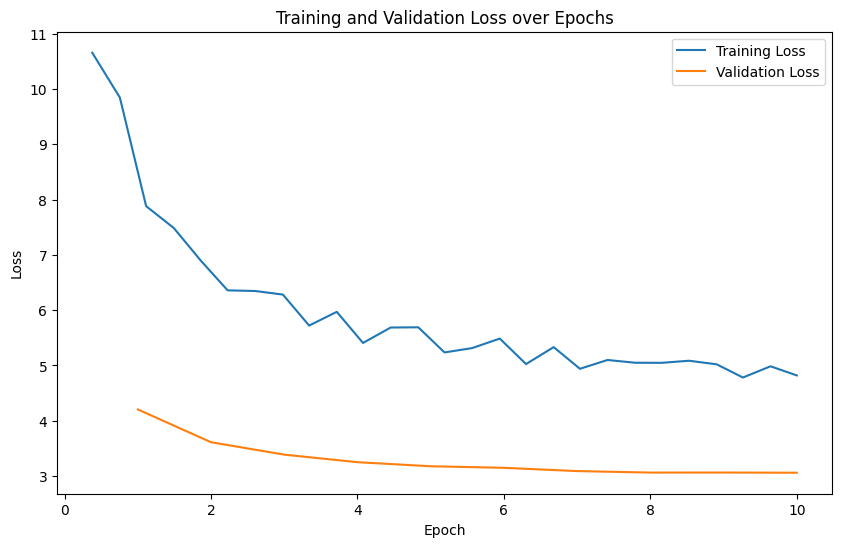

In [11]:
# ...existing code...
# learning curve
import matplotlib.pyplot as plt

# Access the logs from the trainer state
log_history = trainer.state.log_history

# Separate training and validation logs
train_loss = [x['loss'] for x in log_history if 'loss' in x]
train_epochs = [x['epoch'] for x in log_history if 'loss' in x]

eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_epochs = [x['epoch'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 6))
plt.plot(train_epochs, train_loss, label='Training Loss')
if eval_loss:
    plt.plot(eval_epochs, eval_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

In [12]:
# ...existing code...
def generate_user_story(spec: str, epic: str, related_stories: list[str], model, tokenizer, max_new_tokens: int = 150) -> str:
    model.eval()
    
    related_text = "\n- ".join(related_stories) if related_stories else "None"
    prompt = (
        f"Project Specification:\n{spec}\n\n"
        f"Epic: {epic}\n\n"
        f"Related User Stories:\n- {related_text}\n\n"
        f"Generate a new User Story:\n"
    )
    
    # 1. Truncate inputs to fit model context
    # distilgpt2 context size is 1024. We need to leave room for the generated tokens.
    try:
        max_input_length = model.config.n_ctx - max_new_tokens
    except :
        max_input_length = 1024 - max_new_tokens  # Default to 1024 if config is missing
    
    device = next(model.parameters()).device
    
    # Truncate from the left (keeping the end of the prompt instructions) or right?
    # Usually for specs, we want the beginning, but we also definitely want the "Generate a new User Story:" instruction at the end.
    # Simple truncation:
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_input_length).to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=inputs['input_ids'].shape[1] + max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_k=50,
            top_p=0.95,
            num_return_sequences=1
        )
    

    # Return only the generated part (careful with truncation matching)
    # Since we might have truncated the prompt, straightforward string slicing might fail if we slice by original prompt len.
    # Better to decode just the new tokens:
    input_len = inputs['input_ids'].shape[1]
    new_tokens = outputs[0][input_len:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

spec, user_story, related_stories, epic = test_data[0]

print("Generated User Story:\n", generate_user_story(spec, epic, related_stories, model, tokenizer))

Generated User Story:
 As a collection manager I want to filter on certain fields so I can create categories, group items, see all Items in a collection, create categories, delete.


In [13]:
print("Generated User Story:\n", generate_user_story(spec, epic, related_stories, control, tokenizer))

Generated User Story:
 Epic: Trigger a workflow to run a cataloger
- I want to trigger a task called “Generate a new cataloger in an item”, this will perform a task that will trigger this activity to run on item 2.

- I want to trigger a task to run a cataloger, this will add to the end of this collection item, the cataloger must be added to the end of this item as the user must give a name for the new item.

- This is going to include a form type that can be created by the user, it has a form that the user fills in and it has a default title. This can be a custom title that can be added by the user as long as


In [14]:
from bert_score import score as bert_score

y = []
y_hat_sft = []
y_hat_control = []
rouge_sft = []
rouge_control = []

rouge = evaluate.load('rouge')

for elem in tqdm(test_data):
    spec, user_story, related_stories, epic = elem
    y.append(user_story)
    y_hat_sft.append(generate_user_story(spec, epic, related_stories, model, tokenizer))
    y_hat_control.append(generate_user_story(spec, epic, related_stories, control, tokenizer))
    
    rouge_sft.append(rouge.compute(predictions=y_hat_sft, references=y))
    rouge_control.append(rouge.compute(predictions=y_hat_control, references=y))

# Compute BERTScore (batch for efficiency)
print("Computing BERTScore for SFT model...")
P_sft, R_sft, F1_sft = bert_score(y_hat_sft, y, lang="en")
bertscore_sft = {
    'precision': P_sft.mean().item(),
    'recall': R_sft.mean().item(),
    'f1': F1_sft.mean().item()
}

print("Computing BERTScore for Control model...")
P_ctrl, R_ctrl, F1_ctrl = bert_score(y_hat_control, y, lang="en", verbose=True)
bertscore_control = {
    'precision': P_ctrl.mean().item(),
    'recall': R_ctrl.mean().item(),
    'f1': F1_ctrl.mean().item()
}

print(f"BERTScore SFT: {bertscore_sft}")
print(f"BERTScore Control: {bertscore_control}")

100%|██████████| 44/44 [01:48<00:00,  2.46s/it]


Computing BERTScore for SFT model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Computing BERTScore for Control model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.15 seconds, 299.39 sentences/sec
BERTScore SFT: {'precision': 0.9145899415016174, 'recall': 0.9146910309791565, 'f1': 0.9144836664199829}
BERTScore Control: {'precision': 0.7906481027603149, 'recall': 0.8262081742286682, 'f1': 0.8078685402870178}


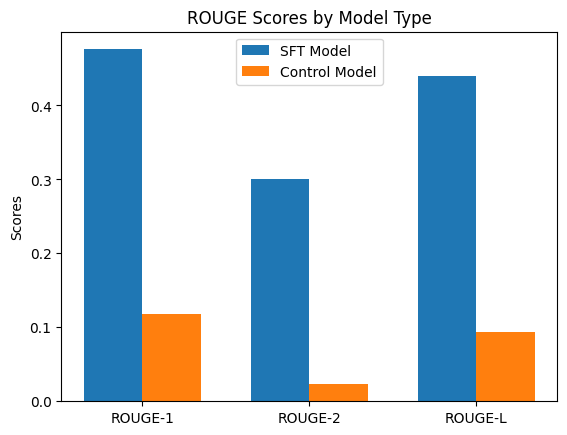

In [15]:
#plot rouge scores comparison
import numpy as np
import matplotlib.pyplot as plt

labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
sft_scores = [np.mean([score['rouge1'] for score in rouge_sft]),
              np.mean([score['rouge2'] for score in rouge_sft]),
              np.mean([score['rougeL'] for score in rouge_sft])]
control_scores = [np.mean([score['rouge1'] for score in rouge_control]),
                  np.mean([score['rouge2'] for score in rouge_control]),
                  np.mean([score['rougeL'] for score in rouge_control])]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, sft_scores, width, label='SFT Model')
rects2 = ax.bar(x + width/2, control_scores, width, label='Control Model') 
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('ROUGE Scores by Model Type')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

In [16]:
R_trident, B_trident = load_data(
    ref_path="datasets/trident/trident_specs.pdf",
    cand_path="datasets/trident/trident_backlog.csv"
)
epic_trident = B_trident.epic.unique()

R_retro, B_retro = load_data(
    ref_path="datasets/retro/retro_specs.pdf",
    cand_path="datasets/retro/retro_backlog.csv"
)
epic_retro = B_retro.epic.unique()

R_alfred, B_alfred = load_data(
    ref_path="datasets/alfred/alfred_specs.pdf",
    cand_path="datasets/alfred/alfred_backlog.csv"
)
epic_alfred = B_alfred.epic.unique()

Rs = {"trident": R_trident, "retro": R_retro, "alfred": R_alfred}
Bs = {"trident": B_trident, "retro": B_retro, "alfred": B_alfred}
epics = {"trident": epic_trident, "retro": epic_retro, "alfred": epic_alfred}

In [17]:
coeur_sft = []
coeur_control = []


B_sft_curs = {"trident": B_trident.copy(), "retro": B_retro.copy(), "alfred": B_alfred.copy()}
B_control_curs = {"trident": B_trident.copy(), "retro": B_retro.copy(), "alfred": B_alfred.copy()}

for i, elem in enumerate(tqdm(test_data)):
    spec, user_story, related_stories, epic = elem
    if epic in epic_trident:
        dataset_name = "trident"
    elif epic in epic_retro:
        dataset_name = "retro"
    elif epic in epic_alfred:
        dataset_name = "alfred"
    
    B_sft_curs[dataset_name].loc[B_sft_curs[dataset_name].user_story == user_story, 'user_story'] = y_hat_sft[i]
    

    B_control_curs[dataset_name].loc[B_control_curs[dataset_name].user_story == user_story, 'user_story'] = y_hat_control[i]
    

100%|██████████| 44/44 [00:00<00:00, 352.82it/s]


In [18]:
# Save generated backlogs for use in ablation studies
import os

output_dir = "experiments/llm_validation/output/sft_backlogs"
os.makedirs(output_dir, exist_ok=True)

for dataset_name in ["trident", "retro", "alfred"]:
    os.makedirs(f"{output_dir}/distilgpt2", exist_ok=True)
    B_sft_curs[dataset_name].to_csv(f"{output_dir}/distilgpt2/{dataset_name}_sft.csv", index=False)
    B_control_curs[dataset_name].to_csv(f"{output_dir}/distilgpt2/{dataset_name}_control.csv", index=False)

print(f"Saved generated backlogs to {output_dir}")

Saved generated backlogs to experiments/llm_validation/output/sft_backlogs


In [19]:
coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True, remove_re_se_stopwords=True, 
              penalize_duplicates=True)
l = "s"
sigma = "ROUGE-2 Precision"

dic_coeur_sft = {"trident": {}, "retro": {}, "alfred": {}}
dic_coeur_control = {"trident": {}, "retro": {}, "alfred": {}}

for dataset_name in ["trident", "retro", "alfred"]:
    dic_coeur_sft[dataset_name] = coeur.score(
        Rs[dataset_name], B_sft_curs[dataset_name], 
        l=l, sigma=sigma, lmbd=0.75
    )
    dic_coeur_control[dataset_name] = coeur.score(
        Rs[dataset_name], B_control_curs[dataset_name], 
        l=l, sigma=sigma, lmbd=0.75
    )

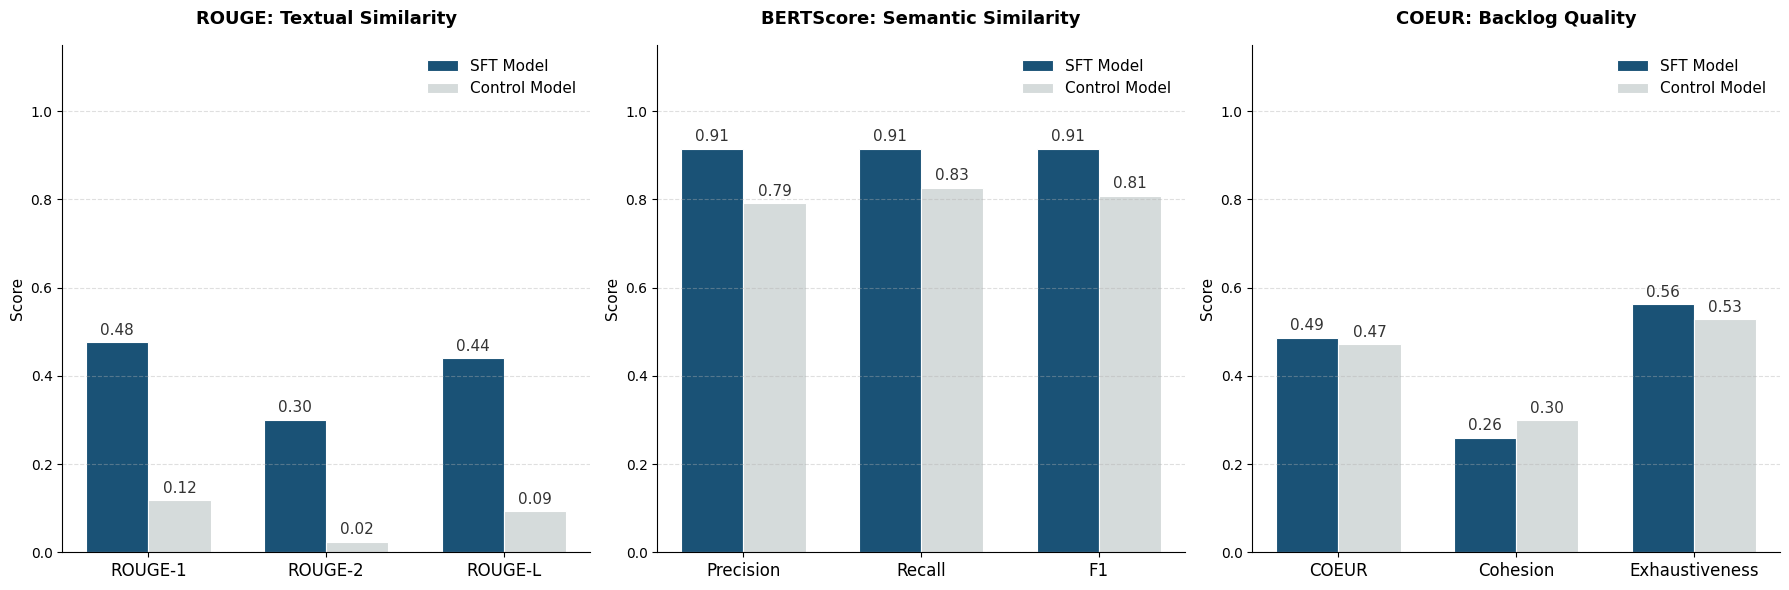

In [20]:
def plot_sft_comparative_results(dic_coeur_sft: dict, dic_coeur_control: dict,
                                  rouge_sft: list = None, rouge_control: list = None,
                                  bertscore_sft: dict = None, bertscore_control: dict = None):
    """
    Plots comparative results for ROUGE, BERTScore, and COEUR metrics.
    All metrics are aggregated across all test samples/datasets.
    
    Args:
        dic_coeur_sft: Dict of {dataset_name: coeur_scores} for SFT model
        dic_coeur_control: Dict of {dataset_name: coeur_scores} for Control model
        rouge_sft: List of ROUGE score dicts for SFT model
        rouge_control: List of ROUGE score dicts for Control model
        bertscore_sft: Dict with 'precision', 'recall', 'f1' for SFT model
        bertscore_control: Dict with 'precision', 'recall', 'f1' for Control model
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

    dataset_names = ["trident", "retro", "alfred"]
    
    # Color palette: SFT (trained) vs Control (baseline)
    strategy_colors = {
        'SFT Model': '#1a5276',      # Dark blue - fine-tuned
        'Control Model': '#d5dbdb'    # Gray - baseline
    }

    # Determine number of plots based on available data
    has_bertscore = bertscore_sft is not None and bertscore_control is not None
    n_plots = 3 if has_bertscore else 2
    
    # Setup Figure - single row with all metrics
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6))
    
    if n_plots == 2:
        ax_rouge, ax_coeur = axes
        ax_bertscore = None
    else:
        ax_rouge, ax_bertscore, ax_coeur = axes

    # --- Plot 1: ROUGE (Aggregated) ---
    if rouge_sft and rouge_control:
        rouge_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
        sft_scores = [
            np.mean([score['rouge1'] for score in rouge_sft]),
            np.mean([score['rouge2'] for score in rouge_sft]),
            np.mean([score['rougeL'] for score in rouge_sft])
        ]
        control_scores = [
            np.mean([score['rouge1'] for score in rouge_control]),
            np.mean([score['rouge2'] for score in rouge_control]),
            np.mean([score['rougeL'] for score in rouge_control])
        ]
        
        x = np.arange(len(rouge_labels))
        bar_width = 0.35
        
        bars1 = ax_rouge.bar(x - bar_width/2, sft_scores, bar_width, 
                             label='SFT Model', color=strategy_colors['SFT Model'],
                             edgecolor='white', linewidth=0.8)
        bars2 = ax_rouge.bar(x + bar_width/2, control_scores, bar_width,
                             label='Control Model', color=strategy_colors['Control Model'],
                             edgecolor='white', linewidth=0.8)
        
        # Add value labels
        for bar, val in zip(bars1, sft_scores):
            ax_rouge.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                         f'{val:.2f}', ha='center', va='bottom', fontsize=11, color='#333')
        for bar, val in zip(bars2, control_scores):
            ax_rouge.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                         f'{val:.2f}', ha='center', va='bottom', fontsize=11, color='#333')
        
        ax_rouge.set_xticks(x)
        ax_rouge.set_xticklabels(rouge_labels, fontsize=12)
        ax_rouge.set_ylim(0, 1.15)
        ax_rouge.set_ylabel("Score", fontsize=11)
        ax_rouge.set_title("ROUGE: Textual Similarity", fontweight='bold', pad=15, fontsize=13)
        ax_rouge.grid(axis='y', linestyle='--', alpha=0.4)
        ax_rouge.spines['top'].set_visible(False)
        ax_rouge.spines['right'].set_visible(False)
        ax_rouge.legend(loc='upper right', frameon=False, fontsize=11)

    # --- Plot 2: BERTScore (Aggregated) ---
    if ax_bertscore is not None and bertscore_sft and bertscore_control:
        bert_labels = ['Precision', 'Recall', 'F1']
        sft_bert_scores = [
            bertscore_sft['precision'],
            bertscore_sft['recall'],
            bertscore_sft['f1']
        ]
        control_bert_scores = [
            bertscore_control['precision'],
            bertscore_control['recall'],
            bertscore_control['f1']
        ]
        
        x = np.arange(len(bert_labels))
        bar_width = 0.35
        
        bars1 = ax_bertscore.bar(x - bar_width/2, sft_bert_scores, bar_width, 
                                  label='SFT Model', color=strategy_colors['SFT Model'],
                                  edgecolor='white', linewidth=0.8)
        bars2 = ax_bertscore.bar(x + bar_width/2, control_bert_scores, bar_width,
                                  label='Control Model', color=strategy_colors['Control Model'],
                                  edgecolor='white', linewidth=0.8)
        
        # Add value labels
        for bar, val in zip(bars1, sft_bert_scores):
            ax_bertscore.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                             f'{val:.2f}', ha='center', va='bottom', fontsize=11, color='#333')
        for bar, val in zip(bars2, control_bert_scores):
            ax_bertscore.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                             f'{val:.2f}', ha='center', va='bottom', fontsize=11, color='#333')
        
        ax_bertscore.set_xticks(x)
        ax_bertscore.set_xticklabels(bert_labels, fontsize=12)
        ax_bertscore.set_ylim(0, 1.15)
        ax_bertscore.set_ylabel("Score", fontsize=11)
        ax_bertscore.set_title("BERTScore: Semantic Similarity", fontweight='bold', pad=15, fontsize=13)
        ax_bertscore.grid(axis='y', linestyle='--', alpha=0.4)
        ax_bertscore.spines['top'].set_visible(False)
        ax_bertscore.spines['right'].set_visible(False)
        ax_bertscore.legend(loc='upper right', frameon=False, fontsize=11)

    # --- Plot 3: COEUR (Aggregated across all datasets) ---
    coeur_labels = ['COEUR', 'Cohesion', 'Exhaustiveness']
    
    # Aggregate COEUR scores across all datasets (mean)
    sft_coeur_scores = [
        np.mean([dic_coeur_sft[ds]['COEUR'] for ds in dataset_names]),
        np.mean([dic_coeur_sft[ds]['Cohesion'] for ds in dataset_names]),
        np.mean([dic_coeur_sft[ds]['Exhaustiveness'] for ds in dataset_names])
    ]
    control_coeur_scores = [
        np.mean([dic_coeur_control[ds]['COEUR'] for ds in dataset_names]),
        np.mean([dic_coeur_control[ds]['Cohesion'] for ds in dataset_names]),
        np.mean([dic_coeur_control[ds]['Exhaustiveness'] for ds in dataset_names])
    ]
    
    x = np.arange(len(coeur_labels))
    bar_width = 0.35
    
    bars1 = ax_coeur.bar(x - bar_width/2, sft_coeur_scores, bar_width, 
                         label='SFT Model', color=strategy_colors['SFT Model'],
                         edgecolor='white', linewidth=0.8)
    bars2 = ax_coeur.bar(x + bar_width/2, control_coeur_scores, bar_width,
                         label='Control Model', color=strategy_colors['Control Model'],
                         edgecolor='white', linewidth=0.8)
    
    # Add value labels
    for bar, val in zip(bars1, sft_coeur_scores):
        ax_coeur.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=11, color='#333')
    for bar, val in zip(bars2, control_coeur_scores):
        ax_coeur.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=11, color='#333')
    
    ax_coeur.set_xticks(x)
    ax_coeur.set_xticklabels(coeur_labels, fontsize=12)
    ax_coeur.set_ylim(0, 1.15)
    ax_coeur.set_ylabel("Score", fontsize=11)
    ax_coeur.set_title("COEUR: Backlog Quality", fontweight='bold', pad=15, fontsize=13)
    ax_coeur.grid(axis='y', linestyle='--', alpha=0.4)
    ax_coeur.spines['top'].set_visible(False)
    ax_coeur.spines['right'].set_visible(False)
    ax_coeur.legend(loc='upper right', frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_sft_comparative_results(dic_coeur_sft, dic_coeur_control, rouge_sft, rouge_control,
                             bertscore_sft, bertscore_control)

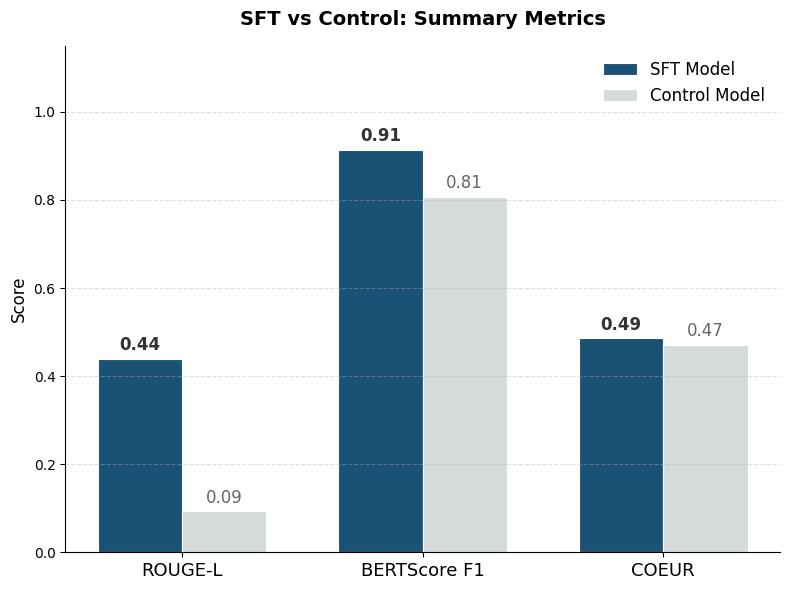

In [21]:
def plot_sft_summary(dic_coeur_sft: dict, dic_coeur_control: dict,
                     rouge_sft: list = None, rouge_control: list = None,
                     bertscore_sft: dict = None, bertscore_control: dict = None,
                     rouge_metric: str = 'rougeL'):
    """
    Simplified comparative plot with single bars for each metric type.
    
    Args:
        dic_coeur_sft: Dict of {dataset_name: coeur_scores} for SFT model
        dic_coeur_control: Dict of {dataset_name: coeur_scores} for Control model
        rouge_sft: List of ROUGE score dicts for SFT model
        rouge_control: List of ROUGE score dicts for Control model
        bertscore_sft: Dict with 'precision', 'recall', 'f1' for SFT model
        bertscore_control: Dict with 'precision', 'recall', 'f1' for Control model
        rouge_metric: Which ROUGE metric to use ('rouge1', 'rouge2', 'rougeL')
    """
    import matplotlib.pyplot as plt
    import numpy as np

    dataset_names = ["trident", "retro", "alfred"]
    
    # Color palette
    strategy_colors = {
        'SFT Model': '#1a5276',
        'Control Model': '#d5dbdb'
    }
    
    # Compute single values for each metric
    labels = ['ROUGE-L', 'BERTScore F1', 'COEUR']
    
    sft_values = [
        np.mean([score[rouge_metric] for score in rouge_sft]) if rouge_sft else 0,
        bertscore_sft['f1'] if bertscore_sft else 0,
        np.mean([dic_coeur_sft[ds]['COEUR'] for ds in dataset_names])
    ]
    
    control_values = [
        np.mean([score[rouge_metric] for score in rouge_control]) if rouge_control else 0,
        bertscore_control['f1'] if bertscore_control else 0,
        np.mean([dic_coeur_control[ds]['COEUR'] for ds in dataset_names])
    ]
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    x = np.arange(len(labels))
    bar_width = 0.35
    
    bars1 = ax.bar(x - bar_width/2, sft_values, bar_width,
                   label='SFT Model', color=strategy_colors['SFT Model'],
                   edgecolor='white', linewidth=0.8)
    bars2 = ax.bar(x + bar_width/2, control_values, bar_width,
                   label='Control Model', color=strategy_colors['Control Model'],
                   edgecolor='white', linewidth=0.8)
    
    # Add value labels
    for bar, val in zip(bars1, sft_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333')
    for bar, val in zip(bars2, control_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.2f}', ha='center', va='bottom', fontsize=12, color='#666')
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=13)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("SFT vs Control: Summary Metrics", fontweight='bold', pad=15, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right', frameon=False, fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Call the summary function
plot_sft_summary(dic_coeur_sft, dic_coeur_control, rouge_sft, rouge_control,
                 bertscore_sft, bertscore_control)